In [ ]:
# @title Setup
from google.cloud import bigquery
from google.colab import data_table
import bigframes.pandas as bpd

project = 'bigtimestudios' # Project ID inserted based on the query results selected to explore
location = 'US' # Location inserted based on the query results selected to explore
client = bigquery.Client(project=project, location=location)
data_table.enable_dataframe_formatter()

In [ ]:
# Running this code will display the query used to generate your previous job

job = client.get_job('bquxjob_c59257d_1940a2e2047') # Job ID inserted based on the query results selected to explore
print(job.query)

select distinct 
event_date,
event_id, 
json_extract_scalar(custom_fields, '$.PlayerSHA256UserID') user_id,
json_extract_scalar(custom_fields, '$.LifetimeRawTimeDiscrepancy') RawtimeDiscrepancy,
json_extract_scalar(custom_fields,"$.CurrentTimeDiscrepancy") CurrentTimeDiscrepancy,
json_extract_scalar(custom_fields,"$.Lifetime") Lifetime,
json_extract_scalar(custom_fields,"$.TimeDiscrepancyDetectedCount") TimeDiscrepancyDetectedCount,
json_extract_scalar(custom_fields,"$.TimeDiscrepancyDetectedOutOfNSeconds") TimeDiscrepancyDetectedOutOfNSeconds,
from `bigtimestudios.game_analytics.design_events` a 
where event_id = "Exploiters:SpeedHack:TimeDiscrepancyDetected"
and event_date >= date_sub(current_date(), interval 14 day) --modified from and event_date >= "2024-05-10"
and json_extract_scalar(custom_fields, '$.PlayerSHA256UserID') is not null



In [ ]:
# Running this code will read results from your previous job

job = client.get_job('bquxjob_c59257d_1940a2e2047') # Job ID inserted based on the query results selected to explore
destination = job.destination

# Load data from a BigQuery table using BigFrames DataFrames:
bq_df = bpd.read_gbq(f"{destination.project}.{destination.dataset_id}.{destination.table_id}")
bq_df.head()

,event_date,event_id,user_id,RawtimeDiscrepancy,CurrentTimeDiscrepancy,Lifetime,TimeDiscrepancyDetectedCount,TimeDiscrepancyDetectedOutOfNSeconds
0,2024-12-23,Exploiters:SpeedHack:TimeDiscrepancyDetected,ecf58089032c0737c44d7c3b96a63473c7644ed543e0ff...,0.188624,3.22366,302.658356,51.0,300.0
1,2024-12-18,Exploiters:SpeedHack:TimeDiscrepancyDetected,b1b1085111edf96f15695bd767a89fe3c162f4f8f2279e...,-0.293675,0.619247,1829.177979,10.0,300.0
2,2024-12-26,Exploiters:SpeedHack:TimeDiscrepancyDetected,a74991aa6a47038631f63153bc88f84c065695a827e4cd...,-0.322087,0.942782,2442.564209,13.0,300.0
3,2024-12-25,Exploiters:SpeedHack:TimeDiscrepancyDetected,cd8c6ed38816e7f459767463828e04fc8f9db704107b51...,0.056764,4.214993,644.542053,72.0,300.0
4,2024-12-23,Exploiters:SpeedHack:TimeDiscrepancyDetected,bf895ca85c56e8159a16f11ad0e9fe1680f168f3a54e6d...,48.334396,45.128422,300.0065,732.0,300.0


In [ ]:
# Generate descriptive statistics.
bq_df.describe()

,event_id,user_id,RawtimeDiscrepancy,CurrentTimeDiscrepancy,Lifetime,TimeDiscrepancyDetectedCount,TimeDiscrepancyDetectedOutOfNSeconds
count,751129,751129,751129,751129,751129,751129,751129
nunique,1,5387,661795,700686,620988,3441,1


In [ ]:
# Convert BigQuery DataFrame to pandas DataFrame.
pandas_df = bq_df.to_pandas()

### Analysis

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [ ]:
# convert columns to float
number_cols = ['RawtimeDiscrepancy','CurrentTimeDiscrepancy', 'Lifetime', 'TimeDiscrepancyDetectedCount','TimeDiscrepancyDetectedOutOfNSeconds']
for col in number_cols:
  pandas_df[col] = pandas_df[col].astype('float64')

sampled = pandas_df.sample(n=10000, random_state=42)

# convert to pandas
sampled = pd.DataFrame(sampled)

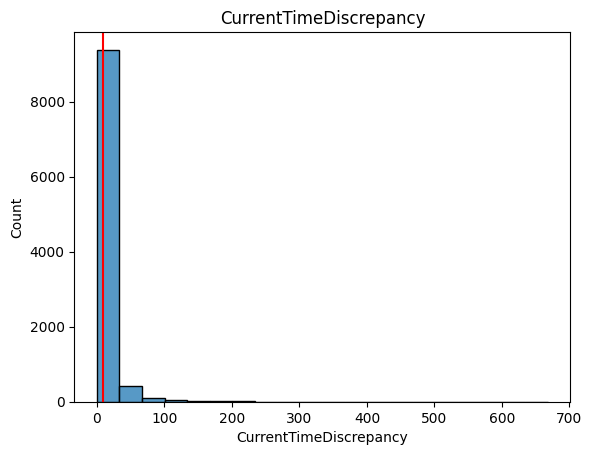

In [ ]:
# get histogram
sns.histplot(x='CurrentTimeDiscrepancy',data=sampled, bins=20)
avg = sampled['CurrentTimeDiscrepancy'].mean()
plt.axvline(avg,color='red',label='Average',linestyle='-')
plt.title('CurrentTimeDiscrepancy')
plt.show()

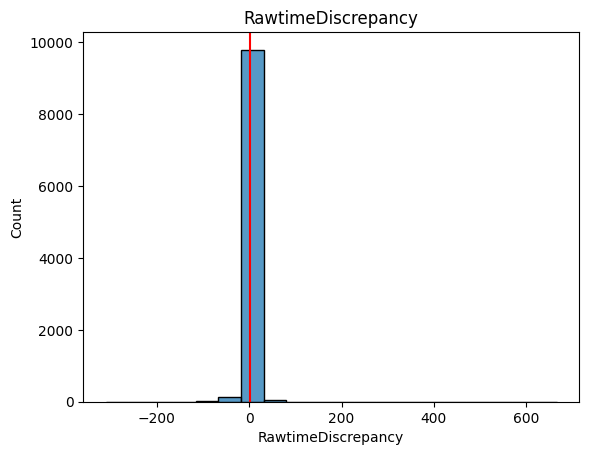

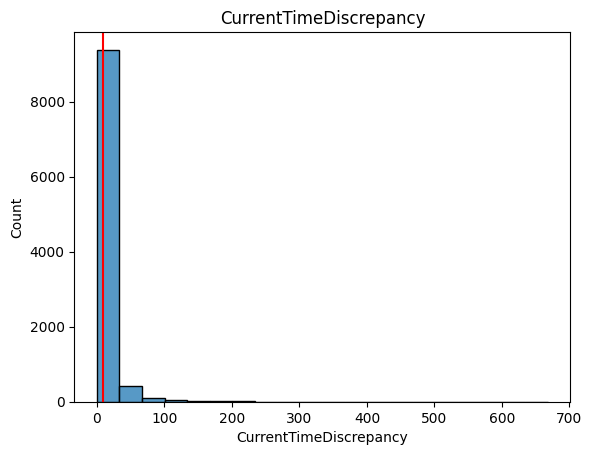

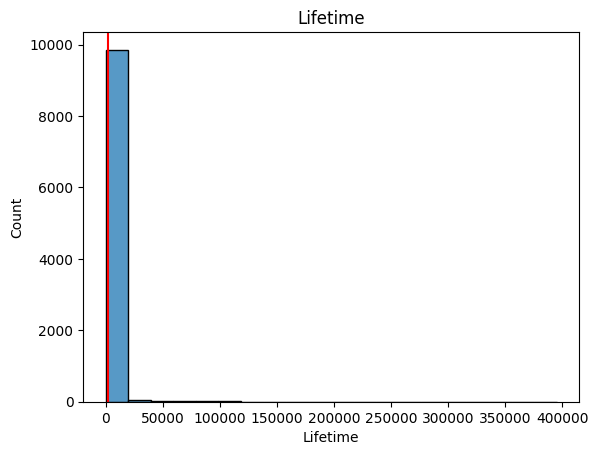

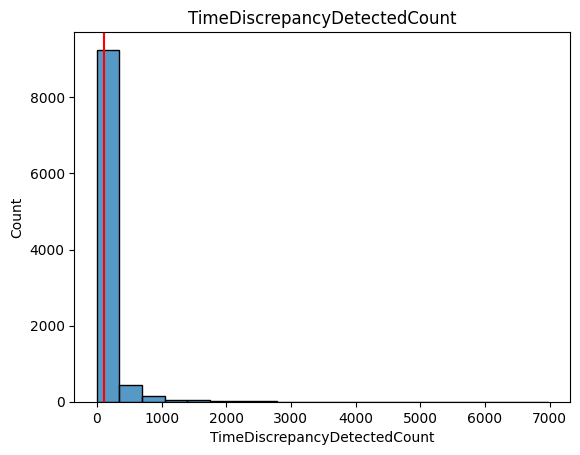

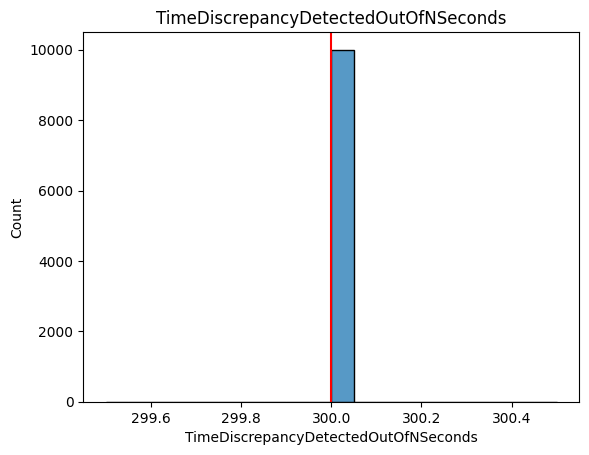

In [ ]:
for col in number_cols:
  sns.histplot(x=col,
               #data=pandas_df,
               data=sampled,
               bins=20)
  avg = sampled[col].mean()
  plt.axvline(avg,color='red',label='Average',linestyle='-')
  plt.title(col)
  plt.show()

In [ ]:
pandas_df.describe()

,event_date,RawtimeDiscrepancy,CurrentTimeDiscrepancy,Lifetime,TimeDiscrepancyDetectedCount,TimeDiscrepancyDetectedOutOfNSeconds
count,751129,751129.000000,751129.000000,751129.000000,751129.000000,751129.0
mean,2024-12-19,1.360859,8.643459,2397.639295,111.671656,300.0
min,2024-12-13,-926.058350,0.050000,0.000000,1.000000,300.0
25%,2024-12-16,-0.215821,1.161765,300.687988,18.000000,300.0
50%,2024-12-19,0.207973,2.371406,607.119080,35.000000,300.0
75%,2024-12-23,1.637812,5.462777,1246.641113,80.000000,300.0
max,2024-12-26,874.481445,869.002563,395071.500000,10171.000000,300.0
std,NaN,18.895256,26.759039,12343.649016,288.445863,0.0


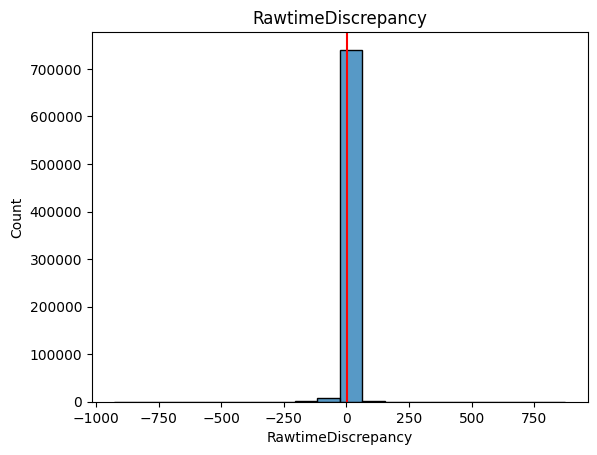

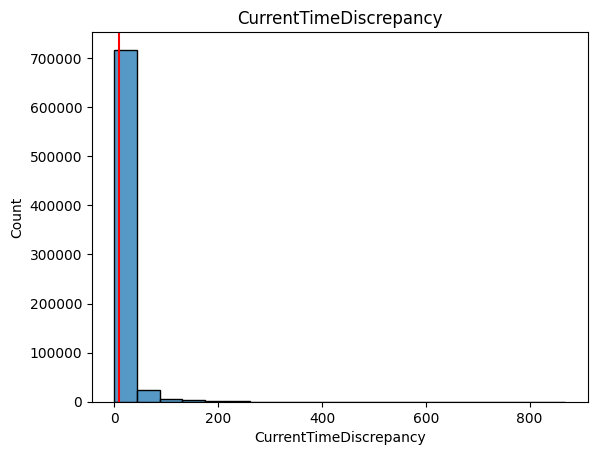

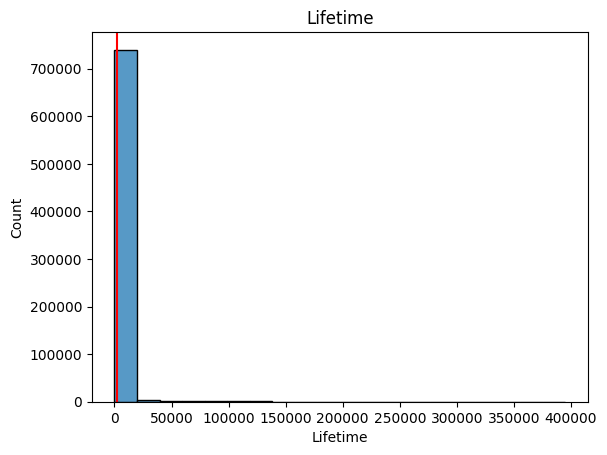

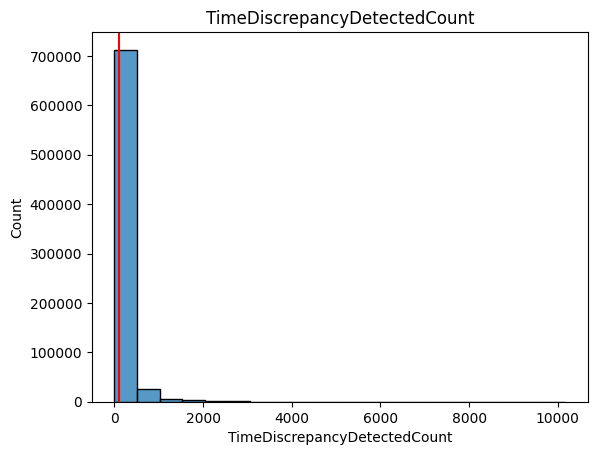

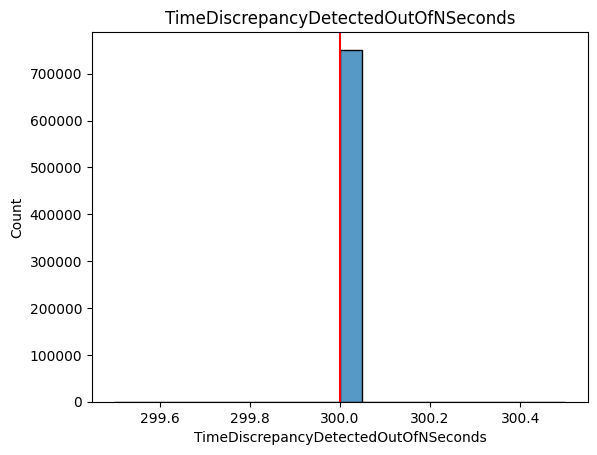

In [ ]:
for col in number_cols:
  sns.histplot(x=col,
               data=pandas_df,
               #data=sampled,
               bins=20)
  avg = sampled[col].mean()
  plt.axvline(avg,color='red',label='Average',linestyle='-')
  plt.title(col)
  plt.show()